# Calibrating Predict inventory impact

This notebook calibrates the optional inventory-impact transfer against a proposed production base fee and a real-world proxy for trader spend. The calibration case comes first; exact Move parity, mechanism demonstrations, and round-trip proofs follow in the appendix.

## North star: why crowded flow should pay more

Crowded flow consumes more of the pool's scarce loss-bearing capacity than an otherwise identical cold or disjoint trade:

- Higher payout liability locks more pool capital into one expiry, leaving less idle capital for LP withdrawals and other markets.
- Concentrating payout on one settlement region increases LP outcome variance and drawdown risk.
- The ordinary base fee prices probability-dependent quote/model risk per contract, but it does not observe the live book.
- Without an inventory transfer, a harmlessly fitting trade pays the same fee as one that materially raises the book's worst-case payout.

Inventory impact is therefore a **refundable congestion bond**, not an ordinary fee and not a settlement-solvency guard. A liability-increasing mint posts escrow. A later voluntary close that removes liability can recover the corresponding potential decrease. If the liability persists through settlement or is removed by liquidation, residual escrow becomes expiry surplus. The policy objective is to make persistent use of scarce expiry capacity costly or compensated while leaving normal flow largely unaffected.

## What this calibration can and cannot answer

This prelaunch analysis answers: *given observed spot-fill spending and assumed Predict book states, what surcharge does each candidate maximum rate produce relative to the base fee?* It cannot identify a statistically optimal production rate because no live Predict distribution yet exists for utilization, overlap, holding time, voluntary closes, or rebates. The result is a conditional policy recommendation whose assumptions are explicit and replaceable when production telemetry exists.

## Variables and working assumptions

| Symbol | Protocol name | Meaning |
|---|---|---|
| $N$ | `net_payout` | Maximum net payout of the trade being priced. This analysis is 1× only, so $N$ equals quantity. |
| $M$ | point maximum | Largest net payout the complete live book owes at any one settlement price. |
| $T$ | total net payout | Sum of each live order's own maximum payout, including mutually exclusive obligations. |
| $g$ | point-maximum movement | How much this trade raises the book's worst settlement point; zero for a cold disjoint order and $N$ for a full pile-on. |
| $\lambda$ | `backing_buffer_lambda` | Fraction of the mutually exclusive gap $T-M$ retained as additional backing; fixed at 0.25. |
| $L$ | `payout_liability` | Live backing requirement $M+\lfloor\lambda(T-M)\rfloor$. |
| $B$ | `inventory_impact_scale` | The expiry's snapshotted `max_expiry_allocation`. The primary case is $50,000, matching the current testnet 1-minute cadence; $250,000–$1 million are retained as sensitivities. |
| $r$ | `inventory_impact_max_rate` | Maximum marginal inventory-impact rate. Candidates span 0.25%–2%. |
| $\Phi(L)$ | inventory-impact potential | A running total whose state change determines the mint charge or live-close rebate. |

A trade that does not lift the point maximum has $g=0$ and changes liability only through the 25% buffer, so $\Delta L/N\approx0.25$. A full pile-on has $g=N$ and $\Delta L/N=1$. The partial-overlap calibration case uses $g/N=0.5$, hence $\Delta L/N=0.625$.

The proposed base-fee curve remains `max(0.20 × sqrt(p × (1-p)), 0.03)` with no expiry ramp/loading. Because that curve varies by probability while inventory impact prices liability, the primary calibration benchmark is its fixed 50%-probability value: **10% of quantity**, called the ATM base-fee reference below. Actual probability-specific fees remain visible as secondary all-in-cost context. The base-fee study rebuilt one quote per second and measured smile self-consistency against Block Scholes' own index; it was not actual volume-weighted Predict flow or a validation against protocol settlement.

In [1]:
%matplotlib inline

from datetime import datetime, timezone
from pathlib import Path
import json
import sys
from urllib.parse import urlencode
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Work both from this notebook's directory and from the repository root.
SIM_DIR = Path.cwd() if (Path.cwd() / "python_indexes").is_dir() else Path.cwd() / "packages/predict/simulations"
if str(SIM_DIR) not in sys.path:
    sys.path.insert(0, str(SIM_DIR))
from python_indexes.strike_payout_tree import StrikePayoutTree

FLOAT = 1_000_000_000
DUSDC = 1_000_000
LAMBDA = 250_000_000

# Calibration policy inputs. Change these values and rerun all cells.
INDEXER_BASE_URL = "https://deepbook-indexer.mainnet.mystenlabs.com"
SPOT_POOL = "XBTC_USDC"
DATA_START_UTC = "2026-07-15"
DATA_END_UTC = "2026-08-14"  # exclusive: one complete 30-day window
DATA_LIMIT = 100_000
MARKET_SCALE_DOLLARS = 50_000  # current testnet 1-minute max_expiry_allocation
SENSITIVITY_SCALES_DOLLARS = (50_000, 250_000, 500_000, 1_000_000)
BASE_FEE_LEVEL = 0.20
BASE_FEE_FLOOR = 0.03
ATM_BASE_REFERENCE_RATE = 0.10  # proposed base fee at p=50%, as a fraction of quantity
PROBABILITIES = np.array([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
CANDIDATE_RATES = np.array([0.0050, 0.0075, 0.0100, 0.0150, 0.0200, 0.0210, 0.0225, 0.0250, 0.0300])
FOCUS_RATE = 0.0200  # conservative round candidate for team review
NORMAL_MAX_REFERENCE_SHARE = 0.10   # normal p95 should stay below 10% of ATM reference
NEAR_CAP_TARGET_REFERENCE_SHARE = 0.20  # near-cap p95 should be about 20% of ATM reference


def mul_down(x: int, y: int) -> int:
    """Move fixed_math::math::mul_down for non-negative values."""
    return x * y // FLOAT


def payout_liability(max_net_payout: int, total_net_payout: int, lam: int = LAMBDA) -> int:
    """Exact live liability: M + floor(lambda * (T - M))."""
    return max_net_payout + mul_down(lam, total_net_payout - max_net_payout)


def phi(liability: int, scale: int, max_rate: int) -> int:
    """Exact integer-operation order of Move inventory_impact_potential_for_liability."""
    if max_rate == 0 or liability == 0:
        return 0
    capped = min(liability, scale)
    utilization = capped * FLOAT // scale
    marginal_rate = mul_down(max_rate, utilization)
    potential_at_cap = mul_down(marginal_rate, capped) // 2
    if liability <= scale:
        return potential_at_cap
    return potential_at_cap + mul_down(max_rate, liability - scale)


def inventory_impact(before: int, after: int, scale: int, max_rate: int) -> int:
    """Potential increase for a mint; swap arguments to value a close rebate."""
    return phi(after, scale, max_rate) - phi(before, scale, max_rate)


def new_tree() -> StrikePayoutTree:
    return StrikePayoutTree(
        min_strike=10,
        tick_size=10,
        max_strike=100,
        neg_inf=0,
        pos_inf=2**64 - 1,
    )


def dollars(atoms: int) -> float:
    return atoms / DUSDC


def base_fee_rate(probability):
    """Proposed base fee, expressed as a fraction of contract quantity."""
    probability = np.asarray(probability, dtype=float)
    return np.maximum(BASE_FEE_LEVEL * np.sqrt(probability * (1 - probability)), BASE_FEE_FLOOR)


def phi_real(liability, scale, max_rate):
    """Real-valued calibration mirror; exact fixed-point parity is gated in the appendix."""
    liability = np.asarray(liability, dtype=float)
    return max_rate * np.where(
        liability <= scale,
        liability**2 / (2 * scale),
        scale / 2 + liability - scale,
    )


def impact_real(before, after, scale, max_rate):
    return phi_real(after, scale, max_rate) - phi_real(before, scale, max_rate)


def unix_seconds(date_string: str) -> int:
    return int(datetime.fromisoformat(date_string).replace(tzinfo=timezone.utc).timestamp())


# Keep all figures deterministic and notebook-local.
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

Matplotlib is building the font cache; this may take a moment.


## Calibration input 1 — observed XBTC/USDC fill spend

The DeepBook Core indexer exposes individual fills for `XBTC_USDC`. We use each fill's USDC `quote_volume` as a deliberately simple proxy for the amount a trader might budget for a Predict position. This is not a demand forecast: one taker order may fragment into several fills, automated market-making flow may dominate, and spot traders need not size Predict positions the same way.

The data window is fixed rather than trailing so repeated notebook runs analyze the same period. The cell fails if the requested API limit is reached, preventing silent truncation.

,value
pool,XBTC_USDC
start UTC,2026-07-15
end UTC (exclusive),2026-08-14
individual fills,45451
total quote volume ($),"9,018,514.6280"
mean fill spend ($),198.4228


,fill spend ($)
0.1000,40.8284
0.2500,101.7184
0.5000,103.8224
0.7500,206.6880
0.9000,402.4022
0.9500,669.4380
0.9900,"1,105.7094"


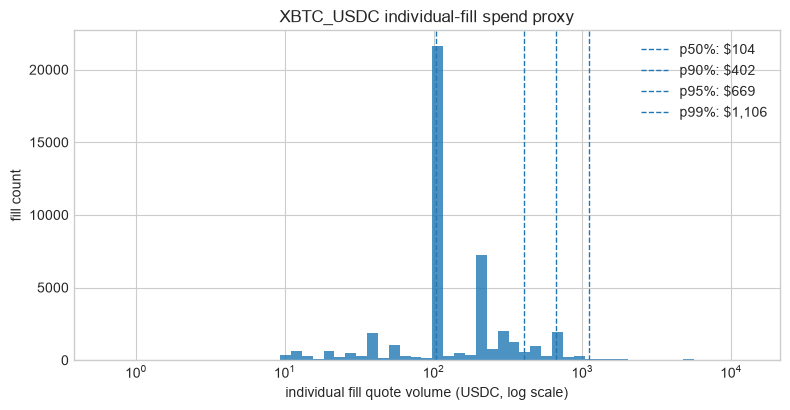

In [2]:
start_seconds = unix_seconds(DATA_START_UTC)
end_seconds = unix_seconds(DATA_END_UTC)
trade_url = f"{INDEXER_BASE_URL}/trades/{SPOT_POOL}?" + urlencode(
    {"start_time": start_seconds, "end_time": end_seconds, "limit": DATA_LIMIT}
)
with urlopen(trade_url, timeout=120) as response:
    raw_fills = json.load(response)

assert raw_fills, "The indexer returned no fills for the configured window."
assert len(raw_fills) < DATA_LIMIT, "The API limit was reached; narrow the window before trusting the distribution."
fills = pd.DataFrame(raw_fills)
fills["spend_usdc"] = pd.to_numeric(fills["quote_volume"])
fills["timestamp_utc"] = pd.to_datetime(fills["timestamp"], unit="ms", utc=True)
assert (fills["spend_usdc"] > 0).all()
assert fills["timestamp_utc"].min() >= pd.Timestamp(DATA_START_UTC, tz="UTC")
assert fills["timestamp_utc"].max() < pd.Timestamp(DATA_END_UTC, tz="UTC")

spend_percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
spend_quantiles = fills["spend_usdc"].quantile(spend_percentiles)
fill_summary = pd.DataFrame(
    {
        "value": [
            SPOT_POOL,
            DATA_START_UTC,
            DATA_END_UTC,
            len(fills),
            fills["spend_usdc"].sum(),
            fills["spend_usdc"].mean(),
        ]
    },
    index=["pool", "start UTC", "end UTC (exclusive)", "individual fills", "total quote volume ($)", "mean fill spend ($)"],
)
display(fill_summary)
display(spend_quantiles.rename("fill spend ($)").to_frame())

fig, ax = plt.subplots(figsize=(8, 4.2))
bins = np.logspace(np.log10(fills["spend_usdc"].min()), np.log10(fills["spend_usdc"].max()), 60)
ax.hist(fills["spend_usdc"], bins=bins, color="tab:blue", alpha=0.8)
for percentile in (0.50, 0.90, 0.95, 0.99):
    value = fills["spend_usdc"].quantile(percentile)
    ax.axvline(value, linestyle="--", linewidth=1, label=f"p{percentile:.0%}: ${value:,.0f}")
ax.set_xscale("log")
ax.set(xlabel="individual fill quote volume (USDC, log scale)", ylabel="fill count", title=f"{SPOT_POOL} individual-fill spend proxy")
ax.legend()
fig.tight_layout()
plt.show()

## Calibration input 2 — translate spend into 1× Predict quantity

At 1×, a contract with probability $p$ has approximate net premium $pN$, so a trader spending $S$ supports quantity and net payout $N=S/p$. We evaluate 5%, 10%, 25%, 50%, 75%, 90%, and 95% contracts. The complementary probabilities matter even though the base-fee curve is symmetric: a fixed dollar budget buys far more quantity on the cheap side of the market.

,quantity p50% ($),quantity p90% ($),quantity p95% ($),quantity p99% ($)
5%,"$2,076.45","$8,048.04","$13,388.76","$22,114.19"
10%,"$1,038.22","$4,024.02","$6,694.38","$11,057.09"
25%,$415.29,"$1,609.61","$2,677.75","$4,422.84"
50%,$207.64,$804.80,"$1,338.88","$2,211.42"
75%,$138.43,$536.54,$892.58,"$1,474.28"
90%,$115.36,$447.11,$743.82,"$1,228.57"
95%,$109.29,$423.58,$704.67,"$1,163.90"


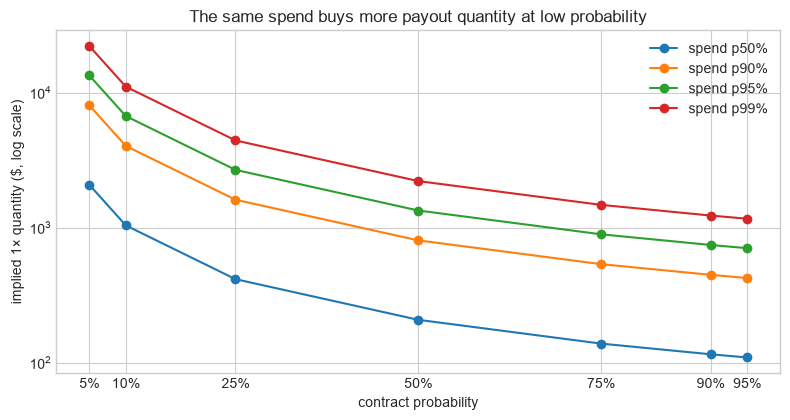

In [3]:
quantity_percentiles = [0.50, 0.90, 0.95, 0.99]
quantity_rows = []
for probability in PROBABILITIES:
    quantities = fills["spend_usdc"] / probability
    row = {"probability": probability}
    row.update({f"quantity p{q:.0%} ($)": quantities.quantile(q) for q in quantity_percentiles})
    quantity_rows.append(row)
quantity_table = pd.DataFrame(quantity_rows).set_index("probability")
quantity_table.index = [f"{p:.0%}" for p in PROBABILITIES]
display(quantity_table.style.format("${:,.2f}").set_caption("1× quantity implied by individual-fill spend"))

fig, ax = plt.subplots(figsize=(8, 4.3))
for percentile in quantity_percentiles:
    ax.plot(
        PROBABILITIES,
        [quantity_table.loc[f"{p:.0%}", f"quantity p{percentile:.0%} ($)"] for p in PROBABILITIES],
        marker="o",
        label=f"spend p{percentile:.0%}",
    )
ax.set_yscale("log")
ax.set_xticks(PROBABILITIES, [f"{p:.0%}" for p in PROBABILITIES])
ax.set(xlabel="contract probability", ylabel="implied 1× quantity ($, log scale)", title="The same spend buys more payout quantity at low probability")
ax.legend()
fig.tight_layout()
plt.show()

## Calibration input 3 — a fixed ATM base-fee reference

The proposed base fee is `max(0.20 × sqrt(p × (1-p)), 0.03)` applied to quantity. It charges 10¢ per dollar of quantity at 50% and declines toward a 3¢ floor in the wings. Using the actual probability-specific fee as the denominator makes the same inventory charge appear larger in the wings, obscuring the liability behavior being calibrated. The primary benchmark below therefore fixes the denominator at the **10% ATM fee rate for every probability**. Actual base fees remain displayed for context. Inventory impact is additive, not discounted, and isolated in refundable escrow rather than recognized immediately as ordinary fee revenue.

,base fee / quantity,"fee on $1,000 quantity"
probability,,
5%,4.36%,$43.59
10%,6.00%,$60.00
25%,8.66%,$86.60
50%,10.00%,$100.00
75%,8.66%,$86.60
90%,6.00%,$60.00
95%,4.36%,$43.59


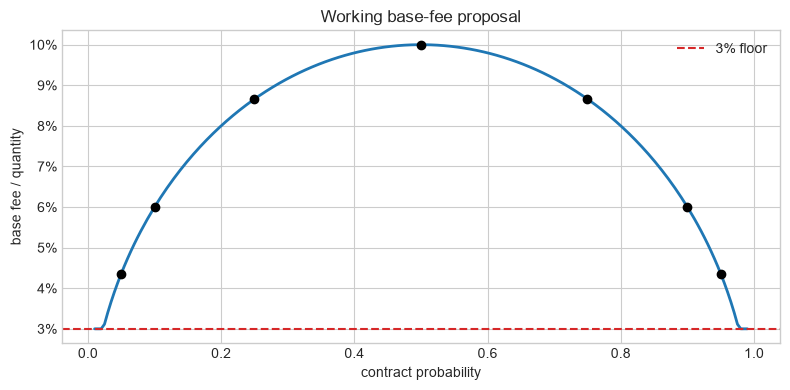

In [4]:
base_rates = base_fee_rate(PROBABILITIES)
base_fee_table = pd.DataFrame(
    {
        "probability": [f"{p:.0%}" for p in PROBABILITIES],
        "base fee / quantity": base_rates,
        "fee on $1,000 quantity": 1_000 * base_rates,
    }
).set_index("probability")
display(base_fee_table.style.format({"base fee / quantity": "{:.2%}", "fee on $1,000 quantity": "${:,.2f}"}))

p_curve = np.linspace(0.01, 0.99, 199)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_curve, base_fee_rate(p_curve), linewidth=2)
ax.scatter(PROBABILITIES, base_rates, color="black", zorder=3)
ax.axhline(BASE_FEE_FLOOR, color="tab:red", linestyle="--", label=f"{BASE_FEE_FLOOR:.0%} floor")
ax.set(xlabel="contract probability", ylabel="base fee / quantity", title="Working base-fee proposal")
ax.yaxis.set_major_formatter(lambda value, _position: f"{value:.0%}")
ax.legend()
fig.tight_layout()
plt.show()

## Core calibration — candidate $r$ relative to the ATM base-fee reference

Explicit book and trade states replace ambiguous labels:

- **50% utilization, partial overlap:** $L/B=50\%$ and $\Delta L/N=0.625$; the p95 trade is the normal-flow guardrail.
- **80% utilization, full pile-on:** $L/B=80\%$ and $\Delta L/N=1$; median and p95 trades show a materially loaded book.
- **95% utilization, full pile-on:** $L/B=95\%$ and $\Delta L/N=1$; the p95 trade is the near-cap stress target.
- **At-cap pile-on:** $L/B=100\%$ and $\Delta L/N=1$; this shows the capped marginal regime.

The primary comparison divides every inventory charge by a fixed ATM base-fee reference equal to 10% of quantity. The working policy shape is: keep the 50%-utilized partial-overlap p95 charge below 10% of that reference, while making the 95%-utilized pile-on p95 charge approximately 20% of the reference. These remain policy judgments for team review. A round `r=2%` is highlighted as the conservative candidate; nearby rates show what is required to reach 20% or 22% more exactly.

,50% partial p95 max / ATM reference,80% pile-on median min / ATM reference,80% pile-on median max / ATM reference,95% pile-on p95 min / ATM reference,95% pile-on p95 max / ATM reference,95% pile-on p95 max / actual base,normal guardrail met,near-cap 20% target met
candidate r,,,,,,,,
0.50%,1.8%,4.0%,4.1%,4.8%,5.0%,11.4%,True,False
0.75%,2.7%,6.0%,6.2%,7.2%,7.5%,17.1%,True,False
1.00%,3.6%,8.0%,8.2%,9.6%,10.0%,22.8%,True,False
1.50%,5.5%,12.0%,12.3%,14.4%,14.9%,34.3%,True,False
2.00%,7.3%,16.0%,16.4%,19.1%,19.9%,45.7%,True,False
2.10%,7.7%,16.8%,17.2%,20.1%,20.9%,48.0%,True,True
2.25%,8.2%,18.0%,18.5%,21.5%,22.4%,51.4%,True,True
2.50%,9.1%,20.0%,20.5%,23.9%,24.9%,57.1%,True,True
3.00%,10.9%,24.0%,24.6%,28.7%,29.9%,68.5%,False,True


Focus candidate r=2.00%: near-cap p95 is 19.1%–19.9% of the ATM reference.


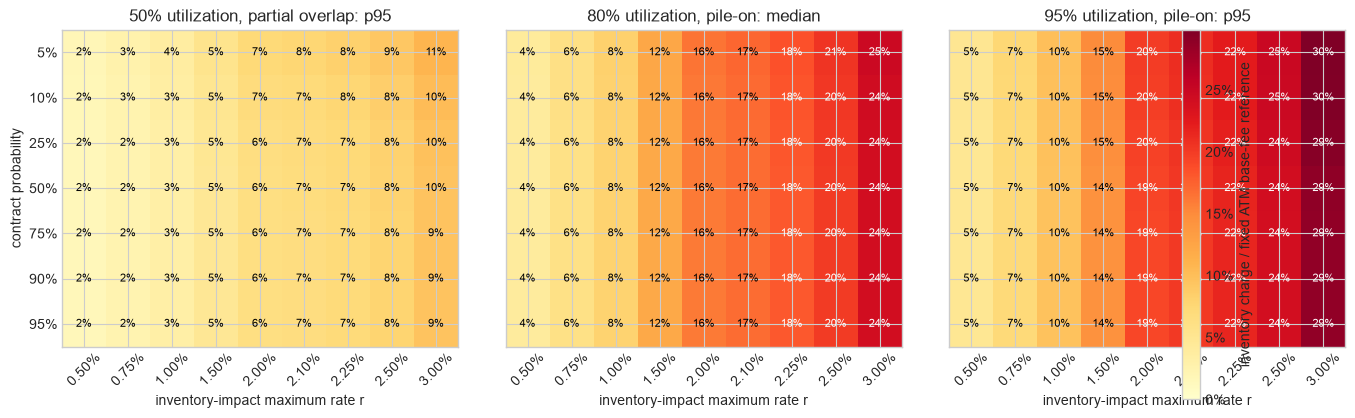

In [5]:
SCENARIOS = {
    "50% utilization, partial overlap": (0.50, 0.625),
    "80% utilization, full pile-on": (0.80, 1.00),
    "95% utilization, full pile-on": (0.95, 1.00),
    "At-cap pile-on": (1.00, 1.00),
}

calibration_rows = []
spend_values = fills["spend_usdc"].to_numpy()
for scenario, (starting_utilization, delta_liability_per_quantity) in SCENARIOS.items():
    before_liability = starting_utilization * MARKET_SCALE_DOLLARS
    for probability in PROBABILITIES:
        quantities = spend_values / probability
        after_liability = before_liability + delta_liability_per_quantity * quantities
        atm_reference_fee = ATM_BASE_REFERENCE_RATE * quantities
        actual_base_fee = base_fee_rate(probability) * quantities
        for rate in CANDIDATE_RATES:
            charges = impact_real(before_liability, after_liability, MARKET_SCALE_DOLLARS, rate)
            relative_to_atm_reference = charges / atm_reference_fee
            relative_to_actual_base = charges / actual_base_fee
            calibration_rows.append(
                {
                    "scenario": scenario,
                    "probability": probability,
                    "r": rate,
                    "charge / ATM reference p50": np.quantile(relative_to_atm_reference, 0.50),
                    "charge / ATM reference p95": np.quantile(relative_to_atm_reference, 0.95),
                    "charge / actual base p95": np.quantile(relative_to_actual_base, 0.95),
                    "charge / quantity p50": np.quantile(charges / quantities, 0.50),
                    "charge / quantity p95": np.quantile(charges / quantities, 0.95),
                    "charge p50 ($)": np.quantile(charges, 0.50),
                    "charge p95 ($)": np.quantile(charges, 0.95),
                }
            )
calibration = pd.DataFrame(calibration_rows)

normal = calibration[calibration["scenario"] == "50% utilization, partial overlap"]
loaded = calibration[calibration["scenario"] == "80% utilization, full pile-on"]
near_cap = calibration[calibration["scenario"] == "95% utilization, full pile-on"]
at_cap = calibration[calibration["scenario"] == "At-cap pile-on"]
decision_table = pd.DataFrame(
    {
        "50% partial p95 max / ATM reference": normal.groupby("r")["charge / ATM reference p95"].max(),
        "80% pile-on median min / ATM reference": loaded.groupby("r")["charge / ATM reference p50"].min(),
        "80% pile-on median max / ATM reference": loaded.groupby("r")["charge / ATM reference p50"].max(),
        "95% pile-on p95 min / ATM reference": near_cap.groupby("r")["charge / ATM reference p95"].min(),
        "95% pile-on p95 max / ATM reference": near_cap.groupby("r")["charge / ATM reference p95"].max(),
        "95% pile-on p95 max / actual base": near_cap.groupby("r")["charge / actual base p95"].max(),
    }
)
decision_table["normal guardrail met"] = decision_table["50% partial p95 max / ATM reference"] <= NORMAL_MAX_REFERENCE_SHARE
decision_table["near-cap 20% target met"] = decision_table["95% pile-on p95 min / ATM reference"] >= NEAR_CAP_TARGET_REFERENCE_SHARE
decision_table.index = [f"{rate:.2%}" for rate in decision_table.index]
decision_table.index.name = "candidate r"
display(
    decision_table.style.format(
        {
            "50% partial p95 max / ATM reference": "{:.1%}",
            "80% pile-on median min / ATM reference": "{:.1%}",
            "80% pile-on median max / ATM reference": "{:.1%}",
            "95% pile-on p95 min / ATM reference": "{:.1%}",
            "95% pile-on p95 max / ATM reference": "{:.1%}",
            "95% pile-on p95 max / actual base": "{:.1%}",
        }
    ).set_caption("Candidate rates relative to a fixed 10%-of-quantity ATM base-fee reference")
)

SELECTED_RATE = FOCUS_RATE
focus = decision_table.loc[f"{FOCUS_RATE:.2%}"]
print(
    f"Focus candidate r={FOCUS_RATE:.2%}: near-cap p95 is "
    f"{focus['95% pile-on p95 min / ATM reference']:.1%}–"
    f"{focus['95% pile-on p95 max / ATM reference']:.1%} of the ATM reference."
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
heatmap_specs = [
    ("50% utilization, partial overlap", "charge / ATM reference p95", "50% utilization, partial overlap: p95"),
    ("80% utilization, full pile-on", "charge / ATM reference p50", "80% utilization, pile-on: median"),
    ("95% utilization, full pile-on", "charge / ATM reference p95", "95% utilization, pile-on: p95"),
]
matrices = []
for scenario, metric, _title in heatmap_specs:
    matrix = (
        calibration[calibration["scenario"] == scenario]
        .pivot(index="probability", columns="r", values=metric)
        .reindex(index=PROBABILITIES, columns=CANDIDATE_RATES)
    )
    matrices.append(matrix)
color_max = max(float(matrix.to_numpy().max()) for matrix in matrices)
for ax, matrix, (_scenario, _metric, title) in zip(axes, matrices, heatmap_specs):
    image = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=color_max, aspect="auto")
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = matrix.iloc[row, col]
            red, green, blue, _ = image.cmap(image.norm(value))
            luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
            ax.text(col, row, f"{value:.0%}", ha="center", va="center", color="black" if luminance > 0.5 else "white", fontsize=8)
    ax.set_xticks(range(len(CANDIDATE_RATES)), [f"{rate:.2%}" for rate in CANDIDATE_RATES], rotation=45)
    ax.set_yticks(range(len(PROBABILITIES)), [f"{p:.0%}" for p in PROBABILITIES])
    ax.set(xlabel="inventory-impact maximum rate r", title=title)
axes[0].set_ylabel("contract probability")
fig.colorbar(image, ax=axes, label="inventory charge / fixed ATM base-fee reference", format=lambda value, _position: f"{value:.0%}")
fig.subplots_adjust(bottom=0.22, wspace=0.12, right=0.88)
plt.show()

## What $B$ actually changes

`B` has two distinct effects that must not be conflated:

1. **Hold utilization fixed:** changing `B` mostly changes the trade-size ratio $N/B$. For ordinary trades small relative to the market allocation, its effect is modest.
2. **Hold the absolute live book fixed:** changing `B` directly changes $L/B$ and therefore the marginal rate. Here `B` can be decisive: $50,000 of liability is 100% utilization when `B=$50,000` but only 5% when `B=$1 million`.

The two panels below use the 95th-percentile XBTC fill translated into 50% contract quantity, a full pile-on, and the highlighted `r=2%` candidate.

,trade quantity ($),fixed 80% utilization: charge / N,fixed $50k liability: starting L/B,fixed $50k liability: charge / N
B ($),,,,
50000,"$1,338.88",1.627%,100%,2.000%
250000,"$1,338.88",1.605%,20%,0.405%
500000,"$1,338.88",1.603%,10%,0.203%
1000000,"$1,338.88",1.601%,5%,0.101%


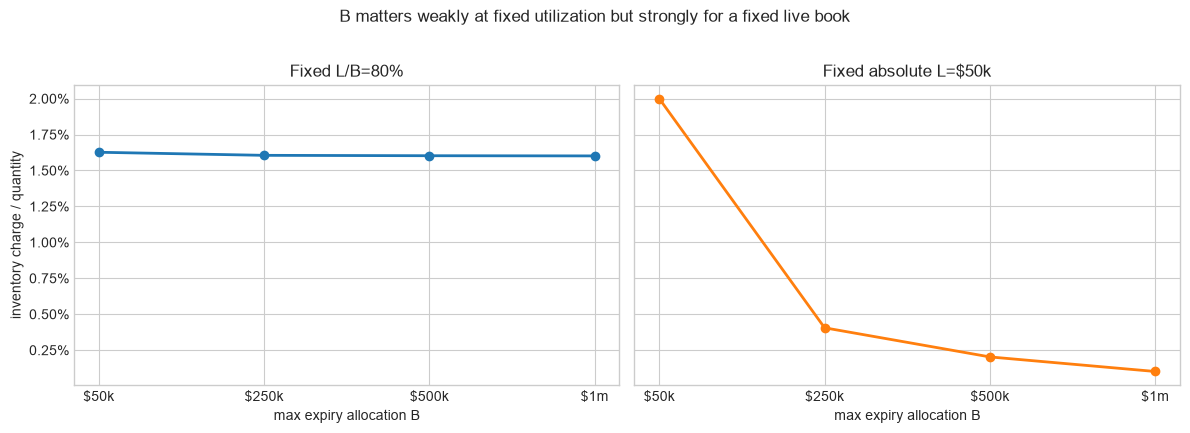

In [6]:
reference_probability = 0.50
reference_spend = fills["spend_usdc"].quantile(0.95)
reference_quantity = reference_spend / reference_probability
fixed_utilization = 0.80
fixed_absolute_liability = 50_000

capacity_rows = []
for scale in SENSITIVITY_SCALES_DOLLARS:
    fixed_u_before = fixed_utilization * scale
    fixed_u_charge = impact_real(fixed_u_before, fixed_u_before + reference_quantity, scale, SELECTED_RATE)
    fixed_l_charge = impact_real(fixed_absolute_liability, fixed_absolute_liability + reference_quantity, scale, SELECTED_RATE)
    capacity_rows.append(
        {
            "B ($)": scale,
            "trade quantity ($)": reference_quantity,
            "fixed 80% utilization: charge / N": float(fixed_u_charge / reference_quantity),
            "fixed $50k liability: starting L/B": fixed_absolute_liability / scale,
            "fixed $50k liability: charge / N": float(fixed_l_charge / reference_quantity),
        }
    )
capacity_table = pd.DataFrame(capacity_rows).set_index("B ($)")
display(
    capacity_table.style.format(
        {
            "trade quantity ($)": "${:,.2f}",
            "fixed 80% utilization: charge / N": "{:.3%}",
            "fixed $50k liability: starting L/B": "{:.0%}",
            "fixed $50k liability: charge / N": "{:.3%}",
        }
    ).set_caption(f"B sensitivity at r={SELECTED_RATE:.2%}, XBTC fill-spend p95=${reference_spend:,.2f}, p=50%")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
x_labels = [f"${scale / 1_000:.0f}k" if scale < 1_000_000 else f"${scale / 1_000_000:.0f}m" for scale in SENSITIVITY_SCALES_DOLLARS]
axes[0].plot(x_labels, capacity_table["fixed 80% utilization: charge / N"], marker="o", linewidth=2)
axes[0].set(title="Fixed L/B=80%", xlabel="max expiry allocation B", ylabel="inventory charge / quantity")
axes[1].plot(x_labels, capacity_table["fixed $50k liability: charge / N"], marker="o", linewidth=2, color="tab:orange")
axes[1].set(title="Fixed absolute L=$50k", xlabel="max expiry allocation B")
for ax in axes:
    ax.yaxis.set_major_formatter(lambda value, _position: f"{value:.2%}")
fig.suptitle("B matters weakly at fixed utilization but strongly for a fixed live book", y=1.02)
fig.tight_layout()
plt.show()

## Interpretation and production backlog

The actionable prelaunch takeaway is **start team review around `r=2%`**, not 0.75%. At the $50,000 testnet scale, the round 2% candidate keeps the 50%-utilized partial-overlap p95 case below the stated 10%-of-ATM-reference guardrail while making the 95%-utilized full-pile-on p95 case roughly one-fifth of the ATM base-fee reference. It is a conservative round choice: `r=2.1%` is approximately the first tested rate that clears a strict 20% floor across every tested probability, while `r=2.25%` moves the same stress case to roughly 22%.

This is not a statistical optimum or a loss-covering estimate. The recommendation says that consuming near-capacity liability should post a noticeable refundable bond while ordinary partial-overlap flow should remain small relative to the base fee. The table deliberately exposes the 50%-utilized p95, 80%-utilized median, and 95%-utilized p95 outcomes so the team can approve or challenge those policy states and targets directly.

Before production calibration can replace this conditional exercise, telemetry should capture each trade's `B`, `L_before/B`, `L_after/B`, $N/B$, $\Delta L/N$, probability, base fee, inventory charge, event type, and eventual voluntary-close rebate. Market-level monitoring should add the time-weighted utilization distribution, time above 50%/80%/95%/100%, and expiry surplus released from residual inventory escrow. Those observations test whether the mechanism actually reduces persistent concentration rather than merely charging the assumed scenarios.

Individual XBTC fills are intentionally only a first sizing proxy. They understate multi-fill order intent and may overweight automated spot flow. Future revisions should compare per-fill, per-taker-order, and actual Predict distributions before changing the production policy.

# Appendix — mechanism correctness and synthetic diagnostics

The remaining executable sections preserve the original parity gate and mechanism exploration. They establish that the Python implementation matches Move arithmetic, explain how payout-tree shape changes liability, demonstrate linearity and path independence, and provide synthetic diagnostics. They support the calibration above but are not themselves evidence for a production rate.

In [7]:
# Appendix parity gate against exact Move test constants.
parity_rows = []

B, r = 4_000_000_000, 200_000_000
worked_cases = [
    ("quadratic first mint", 0, 3_000_000_000, 225_000_000),
    ("crosses L=B", 3_000_000_000, 5_000_000_000, 375_000_000),
    ("cross-range A", 0, 1_000_000_000, 25_000_000),
    ("cross-range B", 1_000_000_000, 1_500_000_000, 31_250_000),
]
for name, before, after, expected in worked_cases:
    actual = inventory_impact(before, after, B, r)
    assert actual == expected, (name, actual, expected)
    parity_rows.append((name, actual, expected))

# ROUNDING_* fixture: evaluate full before/after liabilities so lambda's carry is retained.
rounding_B, rounding_r, rounding_lam = 50_000_000, FLOAT, 333_333_333
rounding_before = payout_liability(100_000_000, 110_000_000, rounding_lam)
rounding_after = payout_liability(100_000_000, 140_000_000, rounding_lam)
assert (rounding_before, rounding_after) == (103_333_333, 113_333_333)
assert (phi(rounding_before, rounding_B, rounding_r), phi(rounding_after, rounding_B, rounding_r)) == (78_333_333, 88_333_333)
rounding_charge = inventory_impact(rounding_before, rounding_after, rounding_B, rounding_r)
assert rounding_charge == 10_000_000
parity_rows.append(("ROUNDING_* buffered carry", rounding_charge, 10_000_000))

# End-to-end flow fixture: 1,000 DUSDC payout, B=10,000 DUSDC, r=20%.
flow_charge = inventory_impact(0, 1_000_000_000, 10_000_000_000, 200_000_000)
assert flow_charge == 10_000_000
parity_rows.append(("flow: mint charge", flow_charge, 10_000_000))

parity_table = pd.DataFrame(parity_rows, columns=["Move fixture", "Python atoms", "Expected atoms"])
display(parity_table)
print("Parity OK: 4 worked assertions, ROUNDING_* carry, and end-to-end flow fixture.")

,Move fixture,Python atoms,Expected atoms
0,quadratic first mint,225000000,225000000
1,crosses L=B,375000000,375000000
2,cross-range A,25000000,25000000
3,cross-range B,31250000,31250000
4,ROUNDING_* buffered carry,10000000,10000000
5,flow: mint charge,10000000,10000000


Parity OK: 4 worked assertions, ROUNDING_* carry, and end-to-end flow fixture.


## Appendix A — reading the potential $\Phi$

$B$ is a market's sizing reference, not a solvency ceiling. Live liability may exceed it; a separate backing invariant requires actual cash to cover liability. The mechanism's marginal rate ramps linearly from zero to $r$ as $L/B$ rises from zero to one, then remains capped at $r$. Thus no additional dollar of liability can ever be charged at more than the chosen maximum rate.

$\Phi$ accumulates that marginal rate. Below $B$, the area under a straight ramp is a triangle, so the ideal real-valued expression is $rL^2/(2B)$. Above $B$, the accumulated triangle is followed by a rectangle, yielding $r[B/2+(L-B)]$. The on-chain implementation computes the same shape through a defined sequence of downward-rounded integer operations, mirrored above.

A trade pays only $\Phi(L_{after})-\Phi(L_{before})$, the area between two liability states. There is no probability, strike, side, or moneyness input. Those details matter only insofar as they change the book-wide liability.

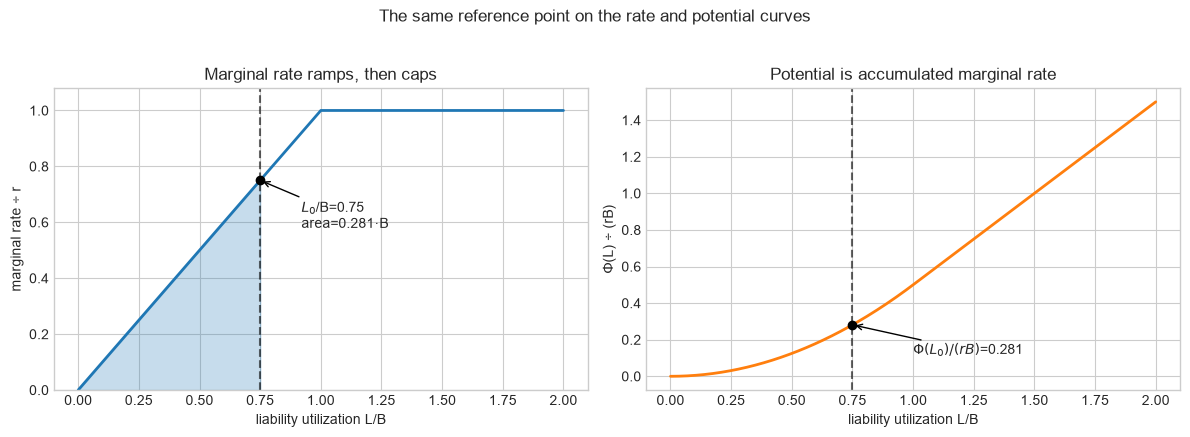

In [8]:
# The fixed shape: marginal-rate ramp and its accumulated potential.
x = np.linspace(0, 2, 401)
marginal_over_r = np.minimum(x, 1.0)
phi_over_rB = np.where(x <= 1, x**2 / 2, 0.5 + (x - 1))
L0 = 0.75
phi0 = L0**2 / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(x, marginal_over_r, color="tab:blue", linewidth=2)
shade_x = x[x <= L0]
axes[0].fill_between(shade_x, 0, np.minimum(shade_x, 1), alpha=0.25, color="tab:blue")
axes[0].scatter([L0], [L0], color="black", zorder=3)
axes[0].axvline(L0, color="black", linestyle="--", alpha=0.6)
axes[0].annotate(f"$L_0$/B={L0:.2f}\narea={phi0:.3f}·B", (L0, L0), xytext=(0.92, 0.58), arrowprops={"arrowstyle": "->"})
axes[0].set(xlabel="liability utilization L/B", ylabel="marginal rate ÷ r", title="Marginal rate ramps, then caps")
axes[0].set_ylim(0, 1.08)

axes[1].plot(x, phi_over_rB, color="tab:orange", linewidth=2)
axes[1].scatter([L0], [phi0], color="black", zorder=3)
axes[1].axvline(L0, color="black", linestyle="--", alpha=0.6)
axes[1].annotate(f"$\\Phi(L_0)/(rB)$={phi0:.3f}", (L0, phi0), xytext=(1.0, 0.12), arrowprops={"arrowstyle": "->"})
axes[1].set(xlabel="liability utilization L/B", ylabel="Φ(L) ÷ (rB)", title="Potential is accumulated marginal rate")
fig.suptitle("The same reference point on the rate and potential curves", y=1.03)
fig.tight_layout()
plt.show()

## Appendix B — book shape determines $\Delta L$

Four canonical shapes separate overlap from price calibration. A first mint creates the point maximum; a pile-on raises an existing maximum by the whole order; a cold disjoint order leaves the maximum unchanged; and partial overlap moves continuously between those endpoints. Here $r$ and $B$ are irrelevant: this part asks only how the payout tree changes $M$, $T$, and therefore $L$.

,L_before ($),L_after ($),ΔL ($),ΔL / N
Shape,,,,
First mint,0.0000,"10,000.0000","10,000.0000",1.0000
Pile-on,"20,000.0000","30,000.0000","10,000.0000",1.0000
"Cold, disjoint","20,000.0000","22,500.0000","2,500.0000",0.2500
Partial overlap (50%),"20,000.0000","26,250.0000","6,250.0000",0.6250


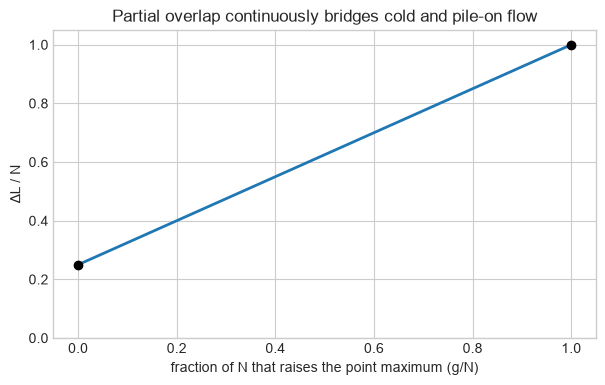

In [9]:
N = 10_000 * DUSDC

# Exact payout-tree cases.
first = new_tree()
first_before = first.net_payout_reserve_terms()
first.insert_range(20, 50, N, 0)
first_after = first.net_payout_reserve_terms()

pile = new_tree()
pile.insert_range(20, 50, 2 * N, 0)
pile_before = pile.net_payout_reserve_terms()
pile.insert_range(20, 50, N, 0)
pile_after = pile.net_payout_reserve_terms()

cold = new_tree()
cold.insert_range(20, 40, 2 * N, 0)
cold_before = cold.net_payout_reserve_terms()
cold.insert_range(60, 80, N, 0)
cold_after = cold.net_payout_reserve_terms()


def liability_pair(before_terms, after_terms, lam=LAMBDA):
    return payout_liability(*before_terms, lam), payout_liability(*after_terms, lam)


def partial_terms(overlap_fraction: float):
    """Parameterize g/N while keeping the order's total net payout fixed."""
    before = (2 * N, 2 * N)
    after = (2 * N + round(overlap_fraction * N), 3 * N)
    return before, after

shape_terms = {
    "First mint": (first_before, first_after),
    "Pile-on": (pile_before, pile_after),
    "Cold, disjoint": (cold_before, cold_after),
    "Partial overlap (50%)": partial_terms(0.5),
}
shape_rows = []
for name, (before_terms, after_terms) in shape_terms.items():
    before_L, after_L = liability_pair(before_terms, after_terms)
    shape_rows.append({
        "Shape": name,
        "L_before ($)": dollars(before_L),
        "L_after ($)": dollars(after_L),
        "ΔL ($)": dollars(after_L - before_L),
        "ΔL / N": (after_L - before_L) / N,
    })
shape_table = pd.DataFrame(shape_rows).set_index("Shape")
display(shape_table)

# The analytical continuum must meet the payout-tree endpoints exactly.
overlap = np.linspace(0, 1, 101)
delta_ratios = []
for fraction in overlap:
    before_terms, after_terms = partial_terms(float(fraction))
    before_L, after_L = liability_pair(before_terms, after_terms)
    delta_ratios.append((after_L - before_L) / N)
assert delta_ratios[0] == (liability_pair(cold_before, cold_after)[1] - liability_pair(cold_before, cold_after)[0]) / N
assert delta_ratios[-1] == (liability_pair(pile_before, pile_after)[1] - liability_pair(pile_before, pile_after)[0]) / N

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(overlap, delta_ratios, linewidth=2)
ax.scatter([0, 1], [delta_ratios[0], delta_ratios[-1]], color="black", zorder=3)
ax.set(xlabel="fraction of N that raises the point maximum (g/N)", ylabel="ΔL / N", title="Partial overlap continuously bridges cold and pile-on flow")
ax.set_ylim(0, 1.05)
plt.show()

## Appendix C — confirm linearity in $r$

For a fixed book transition, $r$ is a multiplicative scale on the potential. Doubling it doubles the charge, while setting it to zero is a kill switch. The exact fixed-point implementation can round at atom scale, so the cell below chooses aligned values and verifies the expected straight line exactly, not only visually.

,r,charge ($)
0,0.0000,0.0000
1,0.0100,137.5000
2,0.0500,687.5000
3,0.1000,"1,375.0000"
4,0.2500,"3,437.5000"
5,0.5000,"6,875.0000"
6,1.0000,"13,750.0000"


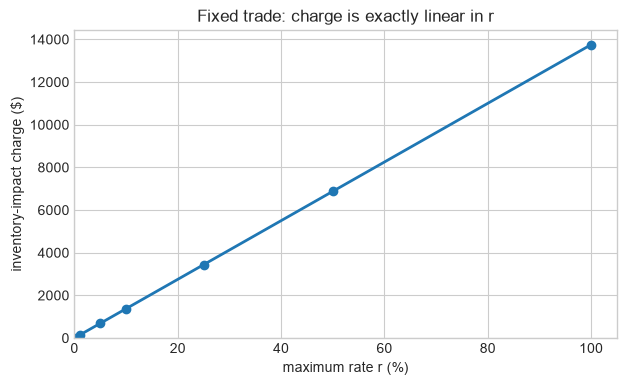

Exact linearity check passed for all plotted rates.


In [10]:
B = 250_000 * DUSDC
L_before = B // 2
trade_N = 25_000 * DUSDC
L_after = L_before + trade_N
rates = np.array([0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.00])
rate_atoms = [round(float(rate) * FLOAT) for rate in rates]
charges = [inventory_impact(L_before, L_after, B, rate) for rate in rate_atoms]
charge_at_full_rate = inventory_impact(L_before, L_after, B, FLOAT)
expected = [rate * charge_at_full_rate // FLOAT for rate in rate_atoms]
assert charges == expected

linearity_table = pd.DataFrame({"r": rates, "charge ($)": [dollars(value) for value in charges]})
display(linearity_table)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(100 * rates, [dollars(value) for value in charges], marker="o", linewidth=2)
ax.set(xlabel="maximum rate r (%)", ylabel="inventory-impact charge ($)", title="Fixed trade: charge is exactly linear in r")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.show()
print("Exact linearity check passed for all plotted rates.")

## Appendix C.1 — the utilization and overlap axes

We now hold a `$25,000` trade and `$250,000` market scale fixed, vary starting utilization, and use each shape's $\Delta L/N$ from Appendix B. The normalized effective rate is `charge / (N × r)`; evaluating at `r=100%` makes it independent of the chosen rate.

One subtle but important result follows from the formula: a cold disjoint trade pins **$\Delta L/N$** at $\lambda$, but its charge is not constant below $B$. The potential prices that smaller liability move at the total book's current marginal rate, so its normalized charge rises with utilization and approaches $\lambda$ once the curve is linear above $B$. This distinguishes liability sensitivity from overlap sensitivity.

L_before / B,10%,50%,90%,110%,200%
Peak-raising (first-mint behavior),0.150,0.550,0.950,1.000,1.000
Pile-on,0.150,0.550,0.950,1.000,1.000
"Cold, disjoint",0.028,0.128,0.228,0.250,0.250
Partial overlap (50%),0.082,0.332,0.582,0.625,0.625


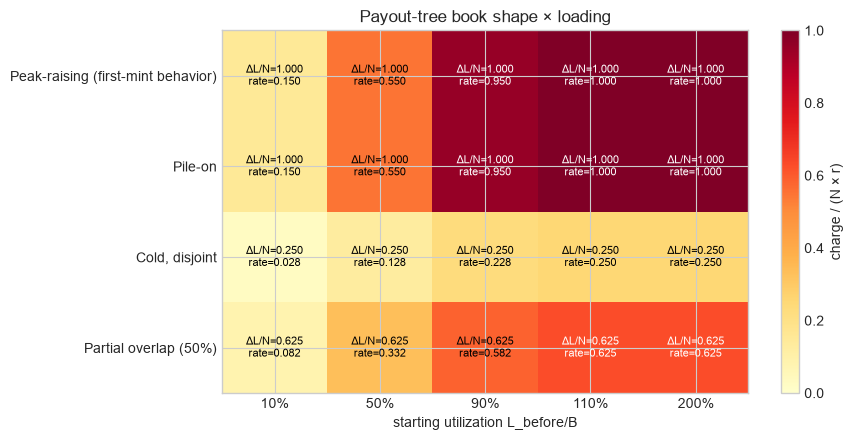

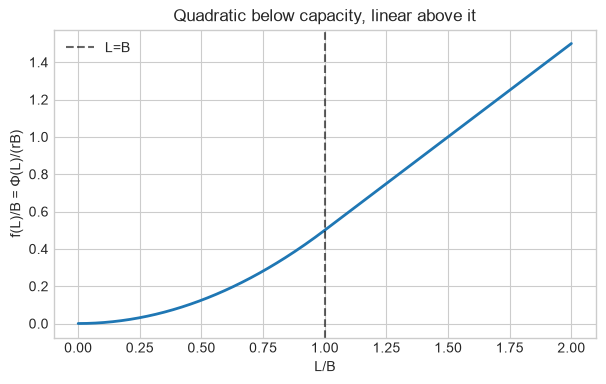

In [11]:
utilizations = np.array([0.10, 0.50, 0.90, 1.10, 2.00])
shape_names = [
    "Peak-raising (first-mint behavior)",
    "Pile-on",
    "Cold, disjoint",
    "Partial overlap (50%)",
]
B = 250_000 * DUSDC
trade_N = 25_000 * DUSDC


def seeded_transition(shape: str, target_liability: int):
    """Construct an exact payout-tree state at target L, then add one order."""
    tree = new_tree()
    if shape in {"Peak-raising (first-mint behavior)", "Pile-on"}:
        tree.insert_range(20, 40, target_liability, 0)
        before_terms = tree.net_payout_reserve_terms()
        tree.insert_range(20, 40, trade_N, 0)
    elif shape == "Cold, disjoint":
        tree.insert_range(20, 40, target_liability, 0)
        before_terms = tree.net_payout_reserve_terms()
        tree.insert_range(60, 80, trade_N, 0)
    else:
        # Existing cold peak M and warm traded-range peak R satisfy R=M-N/2,
        # so the new order raises the point maximum by exactly N/2.
        half_N = trade_N // 2
        guess_M = (target_liability * FLOAT + LAMBDA * half_N) // (FLOAT + LAMBDA)
        candidates = range(max(half_N, guess_M - 10), guess_M + 11)
        M = next(value for value in candidates if payout_liability(value, value + (value - half_N)) == target_liability)
        R = M - half_N
        tree.insert_range(20, 40, M, 0)
        tree.insert_range(60, 80, R, 0)
        before_terms = tree.net_payout_reserve_terms()
        tree.insert_range(60, 80, trade_N, 0)
    after_terms = tree.net_payout_reserve_terms()
    before_L, after_L = liability_pair(before_terms, after_terms)
    assert before_L == target_liability
    return before_L, after_L

matrix = np.zeros((len(shape_names), len(utilizations)))
delta_matrix = np.zeros_like(matrix)
for row, shape in enumerate(shape_names):
    for col, utilization in enumerate(utilizations):
        target = round(float(utilization) * B)
        before, after = seeded_transition(shape, target)
        delta_matrix[row, col] = (after - before) / trade_N
        matrix[row, col] = inventory_impact(before, after, B, FLOAT) / trade_N

loading_table = pd.DataFrame(matrix, index=shape_names, columns=[f"{u:.0%}" for u in utilizations])
loading_table.columns.name = "L_before / B"
display(loading_table.style.format("{:.3f}").set_caption("Normalized effective rate: charge / (N × r)"))

fig, ax = plt.subplots(figsize=(9, 4.5))
image = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        red, green, blue, _ = image.cmap(image.norm(matrix[row, col]))
        luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
        text_color = "black" if luminance > 0.5 else "white"
        ax.text(col, row, f"ΔL/N={delta_matrix[row, col]:.3f}\nrate={matrix[row, col]:.3f}", ha="center", va="center", fontsize=8, color=text_color)
ax.set_xticks(range(len(utilizations)), [f"{u:.0%}" for u in utilizations])
ax.set_yticks(range(len(shape_names)), shape_names)
ax.set(xlabel="starting utilization L_before/B", title="Payout-tree book shape × loading")
fig.colorbar(image, ax=ax, label="charge / (N × r)")
fig.tight_layout()
plt.show()

# The underlying potential curve, normalized so it is independent of r and B.
x = np.linspace(0, 2, 401)
normalized_f = np.where(x <= 1, x**2 / 2, 0.5 + x - 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, normalized_f, linewidth=2)
ax.axvline(1, color="black", linestyle="--", alpha=0.6, label="L=B")
ax.set(xlabel="L/B", ylabel="f(L)/B = Φ(L)/(rB)", title="Quadratic below capacity, linear above it")
ax.legend()
plt.show()

## Appendix D — isolate the finite-trade effect of $B$

Both examples start at the same 50% utilization and receive the same absolute `$25,000` pile-on. This deliberately holds $L/B$ fixed, so it isolates only the finite-trade $N/B$ effect: the smaller market traverses more of the rising ramp. It must not be read as evidence that `B` is generally unimportant; the main calibration section separately shows that `B` strongly changes rates when the absolute live book is held fixed.

,B ($),Trade/B,Charge ($)
0,"250,000.0000",0.1000,"1,375.0000"
1,"1,000,000.0000",0.0250,"1,281.2500"


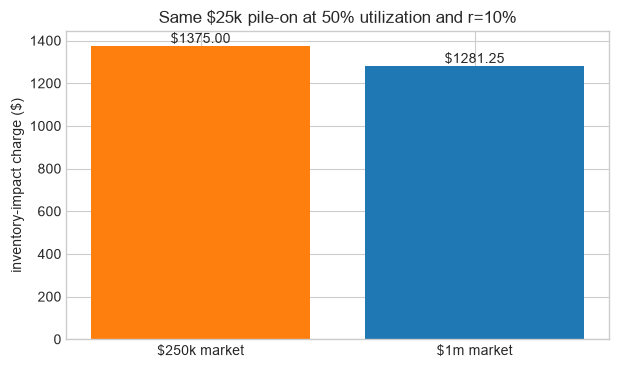

In [12]:
market_scales = [250_000 * DUSDC, 1_000_000 * DUSDC]
trade_N = 25_000 * DUSDC
reference_rate = 100_000_000  # 10%
market_rows = []
for scale in market_scales:
    before = scale // 2
    after = before + trade_N
    charge = inventory_impact(before, after, scale, reference_rate)
    market_rows.append({"B ($)": dollars(scale), "Trade/B": trade_N / scale, "Charge ($)": dollars(charge)})
market_table = pd.DataFrame(market_rows)
display(market_table)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["$250k market", "$1m market"], market_table["Charge ($)"], color=["tab:orange", "tab:blue"])
ax.bar_label(bars, fmt="$%.2f")
ax.set(ylabel="inventory-impact charge ($)", title="Same $25k pile-on at 50% utilization and r=10%")
plt.show()

## Appendix E — legacy illustrative-price section removed

The former fixed `$1,000` premium and `$25` fee comparison was not grounded in the protocol fee curve or observed trade sizing. It has been removed in favor of the base-fee-relative calibration at the top of the notebook.

In [13]:
print("Legacy fixed-premium comparison removed; see the production-fee-relative calibration above.")

Legacy fixed-premium comparison removed; see the production-fee-relative calibration above.


## Appendix F — exact round-trip telescoping

A mint stores an increase in the state potential; a voluntary live close returns the corresponding decrease. The first check mints and closes one range immediately. The second opens two disjoint ranges and closes them in the non-reverse order, so the intermediate rebates differ from the original per-range charges even though the totals must agree.

This property applies to voluntary live closes. Settlement releases unused escrow to pool surplus, and liquidation reduces liability without paying an inventory rebate; those are intentionally different lifecycle rules.

In [14]:
cycle_B = 4_000_000_000
cycle_r = 200_000_000
cycle_lam = 500_000_000
cycle_N = 1_000_000_000


def tree_liability(tree: StrikePayoutTree, lam: int) -> int:
    return payout_liability(*tree.net_payout_reserve_terms(), lam)


def mint_with_charge(tree, lower, higher, amount, scale, rate, lam):
    before = tree_liability(tree, lam)
    tree.insert_range(lower, higher, amount, 0)
    after = tree_liability(tree, lam)
    return inventory_impact(before, after, scale, rate)


def close_with_rebate(tree, lower, higher, amount, scale, rate, lam):
    before = tree_liability(tree, lam)
    tree.remove_range(lower, higher, amount, 0)
    after = tree_liability(tree, lam)
    return inventory_impact(after, before, scale, rate)

# Immediate same-range round trip.
immediate = new_tree()
immediate_charge = mint_with_charge(immediate, 20, 40, cycle_N, cycle_B, cycle_r, cycle_lam)
immediate_rebate = close_with_rebate(immediate, 20, 40, cycle_N, cycle_B, cycle_r, cycle_lam)
assert immediate_charge == immediate_rebate
assert tree_liability(immediate, cycle_lam) == 0

# Open A, open B, close A first, then B.
cross = new_tree()
charge_a = mint_with_charge(cross, 20, 40, cycle_N, cycle_B, cycle_r, cycle_lam)
charge_b = mint_with_charge(cross, 60, 80, cycle_N, cycle_B, cycle_r, cycle_lam)
rebate_a = close_with_rebate(cross, 20, 40, cycle_N, cycle_B, cycle_r, cycle_lam)
rebate_b = close_with_rebate(cross, 60, 80, cycle_N, cycle_B, cycle_r, cycle_lam)
assert (charge_a, charge_b, rebate_a, rebate_b) == (25_000_000, 31_250_000, 31_250_000, 25_000_000)
assert charge_a + charge_b == rebate_a + rebate_b
assert tree_liability(cross, cycle_lam) == 0
assert phi(tree_liability(cross, cycle_lam), cycle_B, cycle_r) == 0

round_trip_table = pd.DataFrame([
    {"Cycle": "same range", "Total charge (atoms)": immediate_charge, "Total rebate (atoms)": immediate_rebate, "Exact equality": immediate_charge == immediate_rebate},
    {"Cycle": "A, B, close A, close B", "Total charge (atoms)": charge_a + charge_b, "Total rebate (atoms)": rebate_a + rebate_b, "Exact equality": charge_a + charge_b == rebate_a + rebate_b},
])
display(round_trip_table)
print("EXACT ROUND-TRIP PASS: integer charge totals equal integer rebate totals in both orderings.")

,Cycle,Total charge (atoms),Total rebate (atoms),Exact equality
0,same range,25000000,25000000,True
1,"A, B, close A, close B",56250000,56250000,True


EXACT ROUND-TRIP PASS: integer charge totals equal integer rebate totals in both orderings.


## Appendix conclusion

The exact checks above establish arithmetic and path independence; they do not select the economic rate. The calibration section supplies explicit utilization/overlap states, observed XBTC individual-fill sizing, both a fixed ATM reference and the actual proposed base-fee curve, and a conservative `r=2%` candidate for policy review. Leverage remains intentionally excluded.